# Scraping Toyosu fish market HTML documents

Toyosu Weekly fish martket report has prices for Bluefin tuna ("tuna") and Bigeye tuna ("bigeye") from the years 2004 -> 2023 in scrape-able html files. Tables should be consistently formatted up to 2023. After 2023 html file becomes pdf document, and I could manually collect the last two or so years.

Data is weekly.

In [6]:
import requests
from bs4 import BeautifulSoup
import csv
import time
import re
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Scrape - trying the first page just to check if it works
    #first scrapable page is January 2023 Week 1

url = "https://www.spt.metro.tokyo.lg.jp/shijou/torihiki/03/suisan/2023013.html"
raw_html = requests.get(url).content
soup_doc = BeautifulSoup(raw_html, "html.parser")
print(soup_doc.prettify())

#content is scrapable!


Making a scraping script that will scrape links with the following format: https://www.spt.metro.tokyo.lg.jp/shijou/torihiki/03/suisan/2004011.html
each website is has a table with information I would like to scrape. 

I don't want to get IP blocked so please add a delay for the process with python's time library, with delay=.25

Each weekly report has the same url with a code denoting date at the back. Format is YYYYMMW (Year, Month, Week) Example: 2004011 - 2004, 01 (January), 1 (week 1) 4 weeks is standard, but some have 5 weeks. 
Try 4 weeks, try the fifth and if that gets a "Not Found," don't add data to the table and proceed to the next month. 

Years: 2004 to 2023
Months: 01 to 12
Weeks: 1 to 4 or 5
I want to pull the following rows: 

マグロ (row named マグロ, and the following row)
メバチ (row named メバチ, and only that one) which can be accomplished with regex, probably

These rows are found within /html/body/center/table/tbody/tr/td/table[3] (the third table element within the outermost table element)
data pulled from each row should be put into the final columns, where data from each cell is divided with a pipe |

save each row to a pd dataframe

In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

BASE_URL = "https://www.spt.metro.tokyo.lg.jp/shijou/torihiki/03/suisan/{}.html"

# Delay between requests (seconds)
REQUEST_DELAY = 0.005

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}

# ── Column definitions ────────────────────────────────────────────────────────
#
# The detail table (section 2) has these columns left-to-right:
#
#  [ITEM BLOCK]          [VOLUME BLOCK]                    [PRICE BLOCK]
#  品目 | 取扱数量t | 週↑↓ | 前週比 | 前年同期比 | 産地 | 等級 | 高値 | 中値 | 安値 | 前週比 | 前年同期比 | (サイズ)
#   0        1         2       3          4          5      6      7      8      9      10         11          12
#
# First sub-row of an item has all 13 cells.
# Continuation sub-rows (extra origin/grade/price combos) only have 8 cells:
#   産地 | 等級 | 高値 | 中値 | 安値 | 前週比 | 前年同期比 | (サイズ)
#    0      1      2      3      4       5          6           7

FULL_ROW_COLS = [
    "品目",            # 0  item name
    "取扱数量t",        # 1  volume (tonnes)
    "週の状況",         # 2  week trend symbol (↑/↓/→ etc.)
    "前週比",           # 3  vs previous week (%)
    "前年同期比",       # 4  vs same period last year (%)
    "産地",             # 5  origin / fishing ground
    "等級",             # 6  grade / size class
    "高値",             # 7  price high (¥/kg)
    "中値",             # 8  price mid  (¥/kg)
    "安値",             # 9  price low  (¥/kg)
    "前週比_価格",      # 10 price vs prev week (%)
    "前年同期比_価格",  # 11 price vs prev year (%)
    "サイズ",           # 12 size note
]

SUB_ROW_COLS = [        # continuation rows: price block only
    "産地",
    "等級",
    "高値",
    "中値",
    "安値",
    "前週比_価格",
    "前年同期比_価格",
    "サイズ",
]

META_COLS = ["year", "month", "week", "code", "url", "row_type", "sub_row"]
ALL_COLS  = META_COLS + FULL_ROW_COLS


# ── Helpers ───────────────────────────────────────────────────────────────────

def build_url_code(year, month, week):
    return f"{year}{month:02d}{week}"


def fetch_page(url):
    """Fetch page decoded as Shift-JIS. Returns HTML string or None if not found."""
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        if resp.status_code == 404:
            return None
        resp.raise_for_status()
        resp.encoding = "shift_jis"
        return resp.text
    except requests.exceptions.HTTPError as e:
        if e.response.status_code == 404:
            return None
        print(f"  HTTP error for {url}: {e}")
        return None
    except requests.exceptions.RequestException as e:
        print(f"  Request error for {url}: {e}")
        return None


def blank_full_row():
    return {col: "" for col in FULL_ROW_COLS}


def map_full_row(cells):
    """Map a 13-cell row to FULL_ROW_COLS dict."""
    row = blank_full_row()
    for i, col in enumerate(FULL_ROW_COLS):
        if i < len(cells):
            row[col] = cells[i]
    return row


def map_sub_row(cells, parent_item):
    """Map an 8-cell continuation row; inherit item name from parent."""
    row = blank_full_row()
    row["品目"] = parent_item
    for i, col in enumerate(SUB_ROW_COLS):
        if i < len(cells):
            row[col] = cells[i]
    return row


# ── Parser ────────────────────────────────────────────────────────────────────

def parse_table(html):
    """
    Return a list of record dicts for マグロ (+ its following row) and メバチ.
    Each dict has keys from FULL_ROW_COLS plus 'row_type' and 'sub_row'.

    row_type values:
      'マグロ'       – first (main) row of マグロ block
      'マグロ_next'  – the sub-row immediately following マグロ (as requested)
      'メバチ'       – メバチ row
    """
    soup = BeautifulSoup(html, "html.parser")
    all_trs = soup.find_all("tr")
    records = []

    i = 0
    while i < len(all_trs):
        tds   = all_trs[i].find_all(["td", "th"])
        cells = [td.get_text(strip=True) for td in tds]

        is_maguro  = any(re.fullmatch(r"マグロ", c) for c in cells)
        is_mebachi = any(re.fullmatch(r"メバチ", c) for c in cells)

        # ── マグロ block ──────────────────────────────────────────────────────
        if is_maguro:
            # Main row
            records.append({
                "row_type": "マグロ",
                "sub_row":  0,
                **map_full_row(cells),
            })
            i += 1

            # Capture ONLY the one immediately following row as マグロ_next
            if i < len(all_trs):
                ntds = all_trs[i].find_all(["td", "th"])
                nc   = [td.get_text(strip=True) for td in ntds]
                nn   = len(nc)
                if nn > 0:
                    first = nc[0]
                    # Only capture if it's not a new named item
                    if not (nn >= 13 and first and first not in ("", "マグロ")):
                        records.append({
                            "row_type": "マグロ_next",
                            "sub_row":  1,
                            **map_sub_row(nc, "マグロ"),
                        })
                        i += 1

            continue  # don't increment i again

        # ── メバチ (single row only) ──────────────────────────────────────────
        if is_mebachi:
            records.append({
                "row_type": "メバチ",
                "sub_row":  0,
                **map_full_row(cells),
            })

        i += 1

    # Return only the last 3 records (マグロ, マグロ_next, メバチ).
    # Using [-3:] drops any earlier duplicates if the pattern appears more than once.
    return records[-3:] if len(records) >= 3 else records


# ── Main ──────────────────────────────────────────────────────────────────────

def main():
    all_records = []

    years     = range(2004, 2024)   # 2004–2023 inclusive
    months    = range(1, 13)
    max_weeks = 5

    for year in years:
        for month in months:
            for week in range(1, max_weeks + 1):
                code = build_url_code(year, month, week)
                url  = BASE_URL.format(code)

                print(f"Fetching {code} ...", end=" ", flush=True)
                html = fetch_page(url)

                if html is None:
                    msg = "Not found (week 5 — skipping)" if week == 5 else "Not found"
                    print(msg)
                    time.sleep(REQUEST_DELAY)
                    continue

                # Only treat as soft 404 if the page clearly has no real content.
                # Avoid bare "404" substring match — it appears in 2023+ document
                # reference numbers (e.g. 令和5年第2号) embedded in the page header,
                # causing valid pages to be incorrectly skipped.
                page_text = re.sub(r"<[^>]+>", " ", html)
                is_soft_404 = bool(
                    re.search(r"ページが見つかり", page_text)
                    or re.search(r"\bnot\s+found\b", page_text, re.IGNORECASE)
                    or re.search(r"HTTP[/ ]*404", page_text, re.IGNORECASE)
                    # bare 404 only counts on very short pages (real error pages are tiny)
                    or (re.search(r"\b404\b", page_text) and len(page_text.strip()) < 2000)
                )
                if is_soft_404:
                    print("Soft 404 (skipping)")
                    time.sleep(REQUEST_DELAY)
                    continue

                rows = parse_table(html)

                if not rows:
                    print("No matching rows")
                else:
                    print(f"{len(rows)} row(s) captured")
                    for row in rows:
                        record = {
                            "year":     year,
                            "month":    month,
                            "week":     week,
                            "code":     code,
                            "url":      url,
                            "row_type": row.pop("row_type"),
                            "sub_row":  row.pop("sub_row"),
                        }
                        record.update(row)
                        all_records.append(record)

                time.sleep(REQUEST_DELAY)

    df = pd.DataFrame(all_records, columns=ALL_COLS)
    print(f"\nDone! {len(df)} rows collected.")
    print(df.head())
    return df


if __name__ == "__main__":
    df = main()

Fetching 2004011 ... 3 row(s) captured
Fetching 2004012 ... 3 row(s) captured
Fetching 2004013 ... 3 row(s) captured
Fetching 2004014 ... 3 row(s) captured
Fetching 2004015 ... Not found (week 5 — skipping)
Fetching 2004021 ... 3 row(s) captured
Fetching 2004022 ... 3 row(s) captured
Fetching 2004023 ... 3 row(s) captured
Fetching 2004024 ... 3 row(s) captured
Fetching 2004025 ... Not found (week 5 — skipping)
Fetching 2004031 ... 3 row(s) captured
Fetching 2004032 ... 3 row(s) captured
Fetching 2004033 ... 3 row(s) captured
Fetching 2004034 ... 3 row(s) captured
Fetching 2004035 ... Not found (week 5 — skipping)
Fetching 2004041 ... 3 row(s) captured
Fetching 2004042 ... 3 row(s) captured
Fetching 2004043 ... 3 row(s) captured
Fetching 2004044 ... 3 row(s) captured
Fetching 2004045 ... 3 row(s) captured
Fetching 2004051 ... 3 row(s) captured
Fetching 2004052 ... 3 row(s) captured
Fetching 2004053 ... 3 row(s) captured
Fetching 2004054 ... 3 row(s) captured
Fetching 2004055 ... Not fou

KeyboardInterrupt: 

In [2]:
df.head(10)

,year,month,week,code,url,row_type,sub_row,品目,取扱数量t,週の状況,前週比,前年同期比,産地,等級,高値,中値,安値,前週比_価格,前年同期比_価格,サイズ
0,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,マグロ,0,マグロ,49.2,74,↓,112,↑,各地,生,"27,300","6,009","2,100",108,94
1,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,マグロ_next,1,マグロ,,,,,海外,生,"9,450","2,987","1,890",112,76,
2,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,メバチ,0,メバチ,97.9,60,↓,82,↓,各地*,冷凍,"4,200","1,095",578,100,111
3,2004,1,2,2004012,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,マグロ,0,マグロ,35.8,73,↓,100,,各地,生,"8,400","5,384","2,625",90,66
4,2004,1,2,2004012,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,マグロ_next,1,マグロ,,,,,海外,生,"5,775","2,387","1,785",80,66,
5,2004,1,2,2004012,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,メバチ,0,メバチ,97.9,100,,85,↓,各地*,冷凍,"4,200","1,055",630,96,111
6,2004,1,3,2004013,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,マグロ,0,マグロ,30.0,84,↓,88,↓,各地,生,"11,550","5,345","2,100",99,92
7,2004,1,3,2004013,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,マグロ_next,1,マグロ,,,,,海外,生,"7,350","2,605","1,680",109,75,
8,2004,1,3,2004013,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,メバチ,0,メバチ,105.1,107,,94,,各地*,冷凍,"4,200","1,049",630,99,112
9,2004,1,4,2004014,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,マグロ,0,マグロ,35.6,119,↑,125,↑,各地,生,"26,250","5,193","1,575",97,79


In [3]:
df.shape

NameError: name 'df' is not defined

In [4]:
# ── Post-processing ───────────────────────────────────────────────────────────

def post_process_dataframe(df):
    """
    Post-process the dataframe to:
    1. Translate Japanese labels to English
    2. Fix alignment of マグロ_next rows (shift data one position right)
    
    Returns a new dataframe with these adjustments applied.
    """
    # Translation mapping
    ja_to_en = {
        "品目": "item",
        "取扱数量t": "volume_tonnes",
        "週の状況": "week_trend",
        "increase_decrease_1": "increase_decrease_1",
        "前週比": "vs_prev_week_pct",
        "increase_decrease_2": "increase_decrease_2",
        "前年同期比": "vs_prev_year_pct",
        "産地": "origin",
        "等級": "grade",
        "高値": "price_high",
        "中値": "price_mid",
        "安値": "price_low",
        "前週比_価格": "price_vs_prev_week_pct",
        "前年同期比_価格": "price_vs_prev_year_pct",
        "サイズ": "size",
    }
    
    row_type_map = {
        "マグロ": "tuna",
        "マグロ_next": "tuna_next",
        "メバチ": "bigeye",
    }
    
    df_copy = df.copy()
    
    # Rename columns from Japanese to English
    rename_cols = {col: ja_to_en.get(col, col) for col in df_copy.columns}
    df_copy = df_copy.rename(columns=rename_cols)
    
    # Translate row_type values
    df_copy["row_type"] = df_copy["row_type"].map(row_type_map)
    
    # Fix alignment for tuna and bigeye rows: shift data LEFT after volume_tonnes
    data_cols = [col for col in df_copy.columns if col not in META_COLS]

    # Find index of volume_tonnes
    volume_idx = data_cols.index("volume_tonnes") if "volume_tonnes" in data_cols else None

    if volume_idx is not None:
        cols_to_shift = data_cols[volume_idx + 1:]  # Start after volume_tonnes
        
        for idx in df_copy.index:
            if df_copy.loc[idx, "row_type"] in ["tuna", "bigeye"]:
                # Get the values for columns that need shifting
                values = df_copy.loc[idx, cols_to_shift].tolist()
                
                # Shift left by one: remove first and append empty
                shifted_values = values[1:] + [""]
                
                # Put shifted values back
                df_copy.loc[idx, cols_to_shift] = shifted_values

    return df_copy


In [5]:
df = post_process_dataframe(df)
#drop url and size columns

In [6]:
df.head()

,year,month,week,code,url,row_type,sub_row,item,volume_tonnes,week_trend,vs_prev_week_pct,vs_prev_year_pct,origin,grade,price_high,price_mid,price_low,price_vs_prev_week_pct,price_vs_prev_year_pct,size
0,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,tuna,0,マグロ,49.2,↓,112,↑,各地,生,"27,300","6,009","2,100",108,94,
1,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,tuna_next,1,マグロ,,,,,海外,生,"9,450","2,987","1,890",112,76,
2,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,bigeye,0,メバチ,97.9,↓,82,↓,各地*,冷凍,"4,200","1,095",578,100,111,
3,2004,1,2,2004012,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,tuna,0,マグロ,35.8,↓,100,,各地,生,"8,400","5,384","2,625",90,66,
4,2004,1,2,2004012,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,tuna_next,1,マグロ,,,,,海外,生,"5,775","2,387","1,785",80,66,


In [7]:
#drop url, size, and vs_prev_year_pct columns
df = df.drop(columns=["url", "size", "vs_prev_year_pct"])
#rename vs_prev_week_pct to year-over-year-comparison
df = df.rename(columns={"vs_prev_week_pct": "year_over_year_comparison"})


In [8]:
df.head(10)

,year,month,week,code,row_type,sub_row,item,volume_tonnes,week_trend,year_over_year_comparison,origin,grade,price_high,price_mid,price_low,price_vs_prev_week_pct,price_vs_prev_year_pct
0,2004,1,1,2004011,tuna,0,マグロ,49.2,↓,112,各地,生,"27,300","6,009","2,100",108,94
1,2004,1,1,2004011,tuna_next,1,マグロ,,,,海外,生,"9,450","2,987","1,890",112,76
2,2004,1,1,2004011,bigeye,0,メバチ,97.9,↓,82,各地*,冷凍,"4,200","1,095",578,100,111
3,2004,1,2,2004012,tuna,0,マグロ,35.8,↓,100,各地,生,"8,400","5,384","2,625",90,66
4,2004,1,2,2004012,tuna_next,1,マグロ,,,,海外,生,"5,775","2,387","1,785",80,66
5,2004,1,2,2004012,bigeye,0,メバチ,97.9,,85,各地*,冷凍,"4,200","1,055",630,96,111
6,2004,1,3,2004013,tuna,0,マグロ,30.0,↓,88,各地,生,"11,550","5,345","2,100",99,92
7,2004,1,3,2004013,tuna_next,1,マグロ,,,,海外,生,"7,350","2,605","1,680",109,75
8,2004,1,3,2004013,bigeye,0,メバチ,105.1,,94,各地*,冷凍,"4,200","1,049",630,99,112
9,2004,1,4,2004014,tuna,0,マグロ,35.6,↑,125,各地,生,"26,250","5,193","1,575",97,79


In [9]:
#drop week_trend, increase_decrease_1, year_over_year_comparison, increase_decrease_2
df = df.drop(columns=["week_trend", "year_over_year_comparison"])

In [10]:
df.head(10)

,year,month,week,code,row_type,sub_row,item,volume_tonnes,origin,grade,price_high,price_mid,price_low,price_vs_prev_week_pct,price_vs_prev_year_pct
0,2004,1,1,2004011,tuna,0,マグロ,49.2,各地,生,"27,300","6,009","2,100",108,94
1,2004,1,1,2004011,tuna_next,1,マグロ,,海外,生,"9,450","2,987","1,890",112,76
2,2004,1,1,2004011,bigeye,0,メバチ,97.9,各地*,冷凍,"4,200","1,095",578,100,111
3,2004,1,2,2004012,tuna,0,マグロ,35.8,各地,生,"8,400","5,384","2,625",90,66
4,2004,1,2,2004012,tuna_next,1,マグロ,,海外,生,"5,775","2,387","1,785",80,66
5,2004,1,2,2004012,bigeye,0,メバチ,97.9,各地*,冷凍,"4,200","1,055",630,96,111
6,2004,1,3,2004013,tuna,0,マグロ,30.0,各地,生,"11,550","5,345","2,100",99,92
7,2004,1,3,2004013,tuna_next,1,マグロ,,海外,生,"7,350","2,605","1,680",109,75
8,2004,1,3,2004013,bigeye,0,メバチ,105.1,各地*,冷凍,"4,200","1,049",630,99,112
9,2004,1,4,2004014,tuna,0,マグロ,35.6,各地,生,"26,250","5,193","1,575",97,79


In [2]:
#get only マグロ rows from each week along with volume_tonnes, price_high, price_mid, price_low, and origin
df_tonne_price_only = df[df["row_type"] == "tuna"][["year", "month", "week", "origin", "volume_tonnes", "price_high", "price_mid", "price_low"]]

NameError: name 'df' is not defined

In [21]:
df_tonne_price_only.head()
#volume_tonnes  should be numeric (float), but they are currently strings
df_tonne_price_only["volume_tonnes"] = pd.to_numeric(df_tonne_price_only["volume_tonnes"], errors="coerce")

#prices should be integers, but are currently strings with commas - remove commas and convert to numeric
for col in ["price_high", "price_mid", "price_low"]:
    df_tonne_price_only[col] = df_tonne_price_only[col].str.replace(",", "")
    df_tonne_price_only[col] = pd.to_numeric(df_tonne_price_only[col], errors="coerce")

df_tonne_price_only.dtypes

#reset index after filtering
df_tonne_price_only = df_tonne_price_only.reset_index(drop=True)

In [ ]:
#approximate conversion:
    #1 tonne = 1000kg
    #1 fish ~ 250kg 
    #round to nearest whole fish
df_tonne_price_only["approx_fish_count"] = ((df_tonne_price_only["volume_tonnes"] * 1000) / 250).round().astype("Int64")
#add week_number (1 through 52, resets each year)
df_tonne_price_only["week_number"] = df_tonne_price_only.index + 1



#add week_id in the format YYYY-MM-WW (e.g. 2023-01-1 for January 2023 Week 1)
df_tonne_price_only["week_id"] = df_tonne_price_only.apply(lambda row: f"{row['year']}-{row['month']:02d}-{row['week']}", axis=1)


df_tonne_price_only.head()

,year,month,week,origin,volume_tonnes,price_high,price_mid,price_low,approx_fish_count,week_number,week_id
0,2004,1,1,各地,49.2,27300.0,6009.0,2100,197,1,2004-01-1
1,2004,1,2,各地,35.8,8400.0,5384.0,2625,143,2,2004-01-2
2,2004,1,3,各地,30.0,11550.0,5345.0,2100,120,3,2004-01-3
3,2004,1,4,各地,35.6,26250.0,5193.0,1575,142,4,2004-01-4
4,2004,2,1,各地,32.0,21000.0,6002.0,1365,128,5,2004-02-1


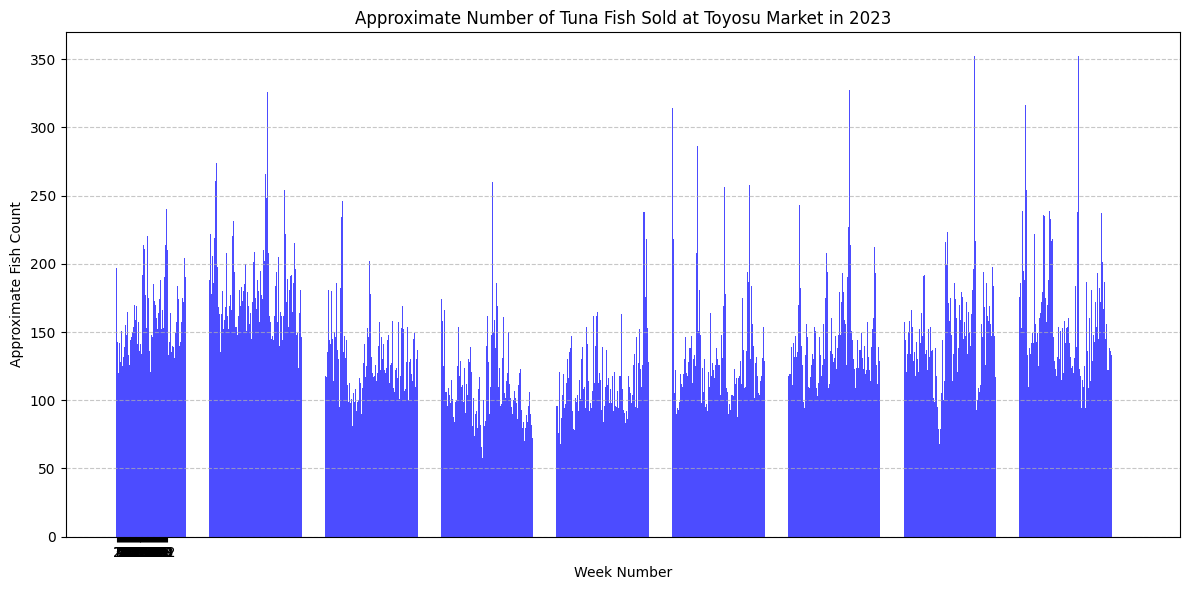

In [ ]:


#barplot. number of fish on y-axis, week_number on x-axis
plt.figure(figsize=(12, 6))
plt.bar(df_tonne_price_only["week_number"], df_tonne_price_only["approx_fish_count"], color="blue", alpha=0.7)
plt.xlabel("Week Number")
plt.ylabel("Approximate Fish Count")
plt.title("Approximate Number of Tuna Fish Sold at Toyosu Market in 2023")
plt.xticks(range(1, 53))  # Show all week numbers on x-axis
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [23]:
#export 2023 tuna price and volume data to CSV
df_tonne_price_only.to_csv("../datasets/toyosu_tuna_04-23.csv", index=False)


In [3]:
#re-import the CSV
df_reimport = pd.read_csv("../datasets/toyosu_tuna_04-23.csv")

In [4]:
df_reimport.head()

,year,month,week,origin,volume_tonnes,price_high,price_mid,price_low,approx_fish_count,week_number,week_id
0,2004,1,1,各地,49.2,27300.0,6009.0,2100,197,1,2004-01-1
1,2004,1,2,各地,35.8,8400.0,5384.0,2625,143,2,2004-01-2
2,2004,1,3,各地,30.0,11550.0,5345.0,2100,120,3,2004-01-3
3,2004,1,4,各地,35.6,26250.0,5193.0,1575,142,4,2004-01-4
4,2004,2,1,各地,32.0,21000.0,6002.0,1365,128,5,2004-02-1


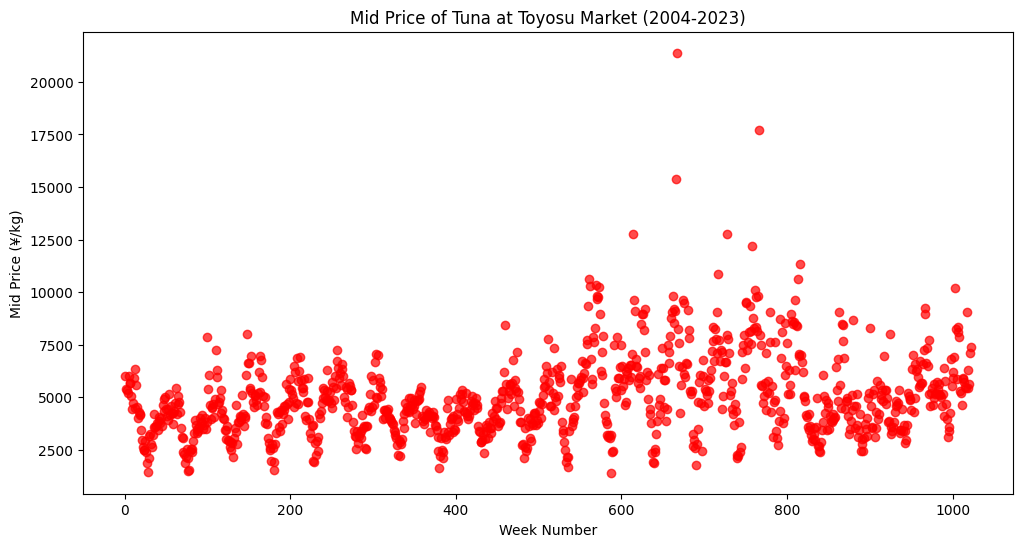

In [13]:
#graph of price_mid over every week since 2004 from df_reimport, week_number on x-axis, no lines
plt.figure(figsize=(12, 6))
plt.scatter(df_reimport["week_number"], df_reimport["price_mid"], color="red", alpha=0.7)
plt.xlabel("Week Number")
plt.ylabel("Mid Price (¥/kg)")
plt.title("Mid Price of Tuna at Toyosu Market (2004-2023)")
plt.show()